## Download Data

In [ ]:
!gdown 13PMixqeLIzuNrFVTFya4AF_qidap-Yeh

Downloading...
From: https://drive.google.com/uc?id=13PMixqeLIzuNrFVTFya4AF_qidap-Yeh
To: /content/advertising.csv
100% 4.06k/4.06k [00:00<00:00, 13.0MB/s]


## Load Data

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

def min_max_scaling(data):
    """
    Performs min-max scaling on the input data.

    Args:
        data: A NumPy array of data.

    Returns:
        A NumPy array with scaled data.
    """
    min_vals = np.min(data, axis=0)
    max_vals = np.max(data, axis=0)
    scaled_data = (data - min_vals) / (max_vals - min_vals)
    return scaled_data


# Load the advertising.csv data using NumPy's genfromtxt function
data = np.genfromtxt('advertising.csv', delimiter=',', skip_header=1)  # Assuming 'advertising.csv' is in the current directory


# Separate features (X) and target (y) if needed. Assuming the last column is the target
X = data[:, :-1]  # All columns except the last one
y = data[:, -1]   # The last column

# Apply min-max scaling to the features
scaled_X = min_max_scaling(X)


print("Original data:\n", X[:5, :])
print("\nScaled data:\n", scaled_X[:5, :])


Original data:
 [[230.1  37.8  69.2]
 [ 44.5  39.3  45.1]
 [ 17.2  45.9  69.3]
 [151.5  41.3  58.5]
 [180.8  10.8  58.4]]

Scaled data:
 [[0.77578627 0.76209677 0.60598065]
 [0.1481231  0.79233871 0.39401935]
 [0.0557998  0.92540323 0.60686016]
 [0.50997633 0.83266129 0.51187335]
 [0.60906324 0.21774194 0.51099384]]


## Huber Loss


In [ ]:
def huber_loss(y_true, y_pred, delta=1.0):
    """Huber Loss"""
    error = y_true - y_pred
    is_small_error = np.abs(error) <= delta
    squared_loss = 0.5 * error ** 2
    linear_loss = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(is_small_error, squared_loss, linear_loss))

def huber_gradient(X_batch, y_batch, y_predicted, delta=1.0):
    n_samples = y_batch.shape[0]
    error = y_predicted - y_batch
    is_small_error = np.abs(error) <= delta
    grad = np.where(is_small_error, error, delta * np.sign(error))
    gradient = (1 / n_samples) * np.dot(X_batch.T, grad)
    return gradient

## Train

In [ ]:
def linear_regression_mini_batch(X, y, loss_fn, gradient_fn, learning_rate=0.01, epochs=1000, batch_size=32, delta=1.0):
    """
    Performs linear regression using mini-batch gradient descent with selectable loss functions.

    Parameters:
    - X: Input features, numpy array of shape (n_samples, n_features)
    - y: Target values, numpy array of shape (n_samples,)
    - loss_fn: Loss function to use
    - gradient_fn: Gradient function corresponding to the loss function
    - learning_rate: Learning rate for gradient descent
    - epochs: Number of times to iterate over the entire dataset
    - batch_size: Number of samples per batch
    - delta: Delta value for Huber and Smooth L1 loss functions

    Returns:
    - weights: Learned weights for the linear model, including bias as the last element
    """
    n_samples, n_features = X.shape

    # Add a column of ones to X for the bias term
    X_bias = np.hstack((X, np.ones((n_samples, 1))))

    # Initialize weights (including bias)
    weights = np.hstack((np.random.uniform(size=n_features), 0.0))

    losses = []
    for epoch in range(epochs):
        # Shuffle the data at the beginning of each epoch
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        X_shuffled = X_bias[indices]
        y_shuffled = y[indices]

        loss_epoch = []
        # Mini-batch gradient descent
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            # Compute predictions
            y_predicted = np.dot(X_batch, weights)

            # Compute loss
            loss = loss_fn(y_batch, y_predicted, delta)
            loss_epoch.append(loss)

            # Compute gradient
            gradient = gradient_fn(X_batch, y_batch, y_predicted, delta)

            # Update parameters
            weights -= learning_rate * gradient

        losses.append(np.mean(loss_epoch))

    return weights, losses

weights, losses = linear_regression_mini_batch(scaled_X, y, huber_loss, huber_gradient, learning_rate=0.001, epochs=1000, batch_size=32, delta=5)

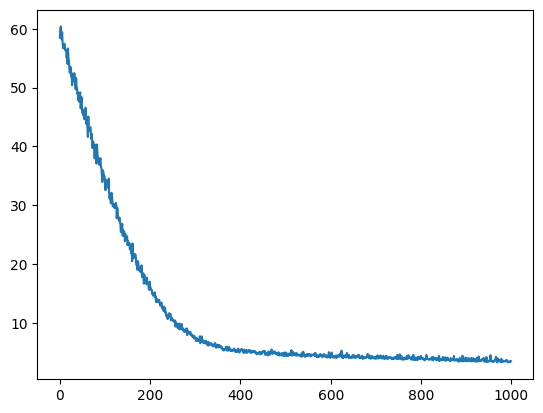

In [ ]:
plt.plot(losses)
plt.show()

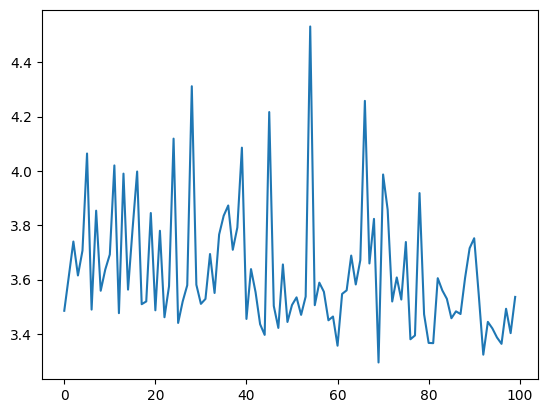

In [ ]:
plt.plot(losses[-100:])
plt.show()